<a href="https://colab.research.google.com/github/mrpintime/Student_Performance_V1/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Team name : Pratik Pokhrel

Roll no: 59    BCT B

Objective

1.Use real data and describe features and target variable.
2. Handle missing values, outliers, encoding, scaling, and train-test split. and so on.

# Student Performance Analysis



# Attribute Information:  

1 school - student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)  
2 sex - student's sex (binary: 'F' - female or 'M' - male)  
3 age - student's age (numeric: from 15 to 22)  
4 address - student's home address type (binary: 'U' - urban or 'R' - rural)  
5 famsize - family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3)  
6 Pstatus - parent's cohabitation status (binary: 'T' - living together or 'A' - apart)  
7 Medu - mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)  
8 Fedu - father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4- higher education)  
9 Mjob - mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')  
10 Fjob - father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')  
11 reason - reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other')  
12 guardian - student's guardian (nominal: 'mother', 'father' or 'other')  
13 traveltime - home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)  
14 studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)  
15 failures - number of past class failures (numeric: n if 1<=n<3, else 4)  
16 schoolsup - extra educational support (binary: yes or no)  
17 famsup - family educational support (binary: yes or no)  
18 paid - extra paid classes within the course subject (Math or Portuguese) (binary: yes or no)  
19 activities - extra-curricular activities (binary: yes or no)  
20 nursery - attended nursery school (binary: yes or no)  
21 higher - wants to take higher education (binary: yes or no)  
22 internet - Internet access at home (binary: yes or no)  
23 romantic - with a romantic relationship (binary: yes or no)  
24 famrel - quality of family relationships (numeric: from 1 - very bad to 5 - excellent)  
25 freetime - free time after school (numeric: from 1 - very low to 5 - very high)  
26 goout - going out with friends (numeric: from 1 - very low to 5 - very high)  
27 Dalc - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)  
28 Walc - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)  
29 health - current health status (numeric: from 1 - very bad to 5 - very good)  
30 absences - number of school absences (numeric: from 0 to 93)  
31 G1 - first period grade (numeric: from 0 to 20)  
31 G2 - second period grade (numeric: from 0 to 20)  
32 G3 - final grade (numeric: from 0 to 20, output target)


# Setup

In [1]:
## import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate, train_test_split
from scipy.stats import pearsonr,f_oneway,ttest_ind
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error








## Load Datasets


In [2]:
df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Dataset Cleaning

## Check Name of Columns

In [3]:
print(df.shape)    
print(df.columns)   
df.head()         

(395, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Outliers detection


In [4]:
 #Remove withdrawn students (G3=0)
df = df[df['G3'] > 0].copy()
print(f"Final dataset: {df.shape[0]} rows")


Final dataset: 357 rows


In [5]:
# Remove remaining G3 outliers via IQR
Q1, Q3 = df['G3'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df['G3'] >= Q1 - 1.5*IQR) & (df['G3'] <= Q3 + 1.5*IQR)].copy()
print(f"Final dataset: {df.shape[0]} rows (removed {357 - df.shape[0]} outliers)")


Final dataset: 357 rows (removed 0 outliers)


## Check for missing values

In [6]:
# Basic Info
df.info()
print(df.duplicated().any())




<class 'pandas.core.frame.DataFrame'>
Index: 357 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      357 non-null    object
 1   sex         357 non-null    object
 2   age         357 non-null    int64 
 3   address     357 non-null    object
 4   famsize     357 non-null    object
 5   Pstatus     357 non-null    object
 6   Medu        357 non-null    int64 
 7   Fedu        357 non-null    int64 
 8   Mjob        357 non-null    object
 9   Fjob        357 non-null    object
 10  reason      357 non-null    object
 11  guardian    357 non-null    object
 12  traveltime  357 non-null    int64 
 13  studytime   357 non-null    int64 
 14  failures    357 non-null    int64 
 15  schoolsup   357 non-null    object
 16  famsup      357 non-null    object
 17  paid        357 non-null    object
 18  activities  357 non-null    object
 19  nursery     357 non-null    object
 20  higher      357

## Target Variable Description

In [7]:
print(df['G3'].describe())

count    357.000000
mean      11.523810
std        3.227797
min        4.000000
25%        9.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


## Histogram of target Variable

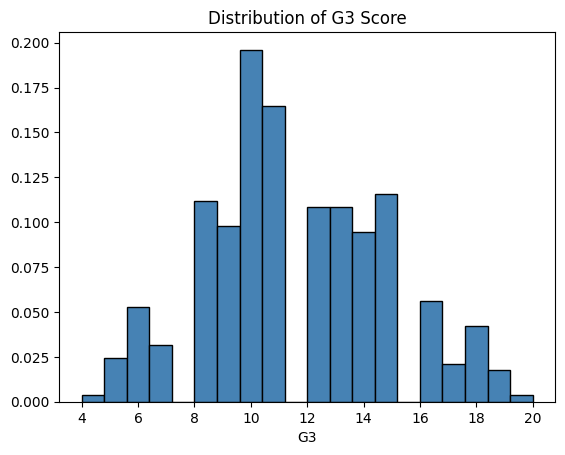

In [8]:
plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='black',density=True)
plt.title('Distribution of G3 Score')
plt.xlabel('G3')
plt.show()



In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop('G3')
corr = df[numeric_cols].corrwith(df['G3']).sort_values()
print(corr)

failures     -0.293831
absences     -0.213129
Walc         -0.190054
goout        -0.177383
Dalc         -0.140690
age          -0.140372
traveltime   -0.099785
health       -0.081691
freetime     -0.021589
famrel        0.037711
studytime     0.126728
Fedu          0.158811
Medu          0.190308
G1            0.891805
G2            0.965583
dtype: float64


## Data Pre-processing


In [10]:


binary_cats = ['sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup',
               'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
multi_cats  = ['school', 'Mjob', 'Fjob', 'reason', 'guardian']

df_encoded = df.copy()

# Binary encoding
for col in binary_cats:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# One-hot encoding 
df_encoded = pd.get_dummies(df_encoded, columns=multi_cats, drop_first=True, dtype=int)


## Hypothesis Testing 


In [11]:


results = []

# Automatically detect column types from ORIGINAL df
numeric_cols    = df.select_dtypes(include=np.number).columns.drop('G3')
categorical_cols = df.select_dtypes(exclude=np.number).columns


# Pearson — numeric features
for col in numeric_cols:
    stat, p = pearsonr(df[col], df['G3'])
    results.append({
        'Feature': col, 'Test': 'Pearson',
        'Statistic': round(stat, 4),
        'p-value': round(p, 4),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

#  T-test or ANOVA — categorical features
for col in categorical_cols:
    groups = [df['G3'][df[col] == cat] for cat in df[col].unique()]
    
    if len(groups) == 2:
        # Binary → T-test
        stat, p = ttest_ind(groups[0], groups[1],equal_var=False)
        test_name = 'T-test'
    else:
        # Multi category → ANOVA
        stat, p = f_oneway(*groups)
        test_name = 'ANOVA'

    results.append({
        'Feature': col, 'Test': test_name,
        'Statistic': round(stat, 4),
        'p-value': round(p, 4),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

hyp_df = pd.DataFrame(results).sort_values('p-value')
print(hyp_df.to_string(index=False))

   Feature    Test  Statistic  p-value Significant
  failures Pearson    -0.2938   0.0000         Yes
  absences Pearson    -0.2131   0.0000         Yes
        G2 Pearson     0.9656   0.0000         Yes
        G1 Pearson     0.8918   0.0000         Yes
 schoolsup  T-test    -5.4608   0.0000         Yes
      Walc Pearson    -0.1901   0.0003         Yes
      Medu Pearson     0.1903   0.0003         Yes
     goout Pearson    -0.1774   0.0008         Yes
      Mjob   ANOVA     4.2504   0.0023         Yes
      Fedu Pearson     0.1588   0.0026         Yes
    higher  T-test     3.5078   0.0028         Yes
      Dalc Pearson    -0.1407   0.0078         Yes
       age Pearson    -0.1404   0.0079         Yes
   address  T-test     2.4784   0.0145         Yes
 studytime Pearson     0.1267   0.0166         Yes
  internet  T-test    -2.2536   0.0268         Yes
      Fjob   ANOVA     2.4743   0.0442         Yes
       sex  T-test    -1.9386   0.0533          No
traveltime Pearson    -0.0998  

## Feature Selection

In [12]:
sig_features = hyp_df[
    (hyp_df['Significant'] =="Yes")
]['Feature'].tolist()

print("Selected features:", sig_features)
print("Number of features:", len(sig_features))


Selected features: ['failures', 'absences', 'G2', 'G1', 'schoolsup', 'Walc', 'Medu', 'goout', 'Mjob', 'Fedu', 'higher', 'Dalc', 'age', 'address', 'studytime', 'internet', 'Fjob']
Number of features: 17


In [13]:
# Map sig_features back to encoded column names
sig_numeric = [f for f in sig_features 
               if f in df.select_dtypes(include=np.number).columns]

dummy_cols = [col for col in df_encoded.columns 
              if any(col.startswith(cat) for cat in sig_features
                     if cat in df.select_dtypes(exclude=np.number).columns)]

final_features = sig_numeric + dummy_cols

## Plot of Selected Features

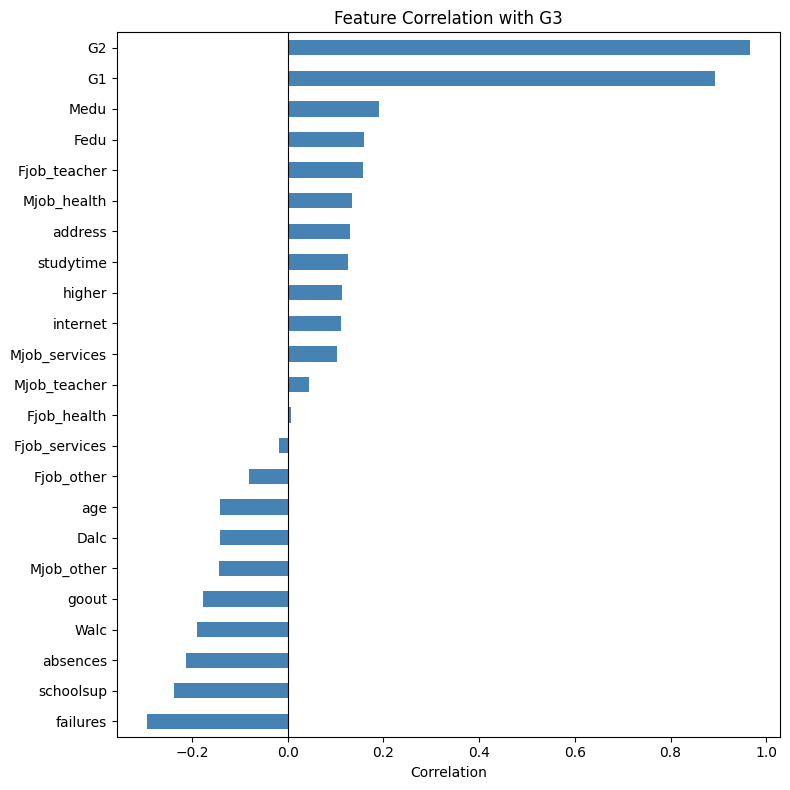

In [14]:
corr_with_g3 = df_encoded[final_features + ['G3']].corr()['G3'].drop('G3').sort_values()

plt.figure(figsize=(8, 8))
corr_with_g3.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with G3')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Multiple Linear Regression with K-cross Validation

In [ ]:

X = df_encoded[final_features]
Y = df['G3']


# Scale features
scaler = StandardScaler()

# Hold out 20% as final unseen test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)   
X_test = scaler.transform(X_test)

#  K-Fold on training data only
mlr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv = cross_validate(mlr, X_train, y_train, cv=kf,
                    scoring=['r2', 'neg_mean_squared_error'],
                    return_train_score=True)

print("── Cross-Validation on Training Set ──")
print(f'CV Train R² : {cv["train_r2"].mean():.4f} ± {cv["train_r2"].std():.4f}')
print(f'CV Test  R² : {cv["test_r2"].mean():.4f} ± {cv["test_r2"].std():.4f}')
print(f'CV Test  MSE: {-cv["test_neg_mean_squared_error"].mean():.4f}')
print(f'CV Test RMSE: {np.sqrt(-cv["test_neg_mean_squared_error"].mean()):.4f}')

#Final evaluation on completely unseen test set
mlr.fit(X_train, y_train)
y_pred_test = mlr.predict(X_test)
y_pred_test = np.clip(y_pred_test, 0, 20)

print("\n── Final Evaluation on Unseen Test Set ──")
print(f'Final Test R² : {r2_score(y_test, y_pred_test):.4f}')
print(f'Final Test MSE : {mean_squared_error(y_test, y_pred_test):.4f}')
print(f'Final Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}')





── Cross-Validation on Training Set ──
CV Train R² : 0.9412 ± 0.0037
CV Test  R² : 0.9240 ± 0.0179
CV Test  MSE: 0.7878
CV Test RMSE: 0.8876

── Final Evaluation on Unseen Test Set ──
Final Test R² : 0.9242
Final Test MSE : 0.7302
Final Test RMSE: 0.8545


## Beta Coefficient


In [16]:
coef_df = pd.DataFrame({
    'Feature': final_features,
    'Coefficient': mlr.coef_
}).sort_values('Coefficient')

print(coef_df.to_string(index=False))
print(f'Intercept : {mlr.intercept_:.4f}')



      Feature  Coefficient
   Mjob_other    -0.114254
         Fedu    -0.089088
        goout    -0.087418
     absences    -0.064711
         Dalc    -0.046174
Mjob_services    -0.008624
  Mjob_health     0.001080
       higher     0.001309
         Medu     0.008695
    studytime     0.008853
     failures     0.010444
    schoolsup     0.016887
      address     0.016981
         Walc     0.028495
          age     0.042025
     internet     0.050732
  Fjob_health     0.069498
 Mjob_teacher     0.076769
 Fjob_teacher     0.084469
Fjob_services     0.124313
   Fjob_other     0.178191
           G1     0.383643
           G2     2.779898
Intercept : 11.5474


## Prediction and Visualization

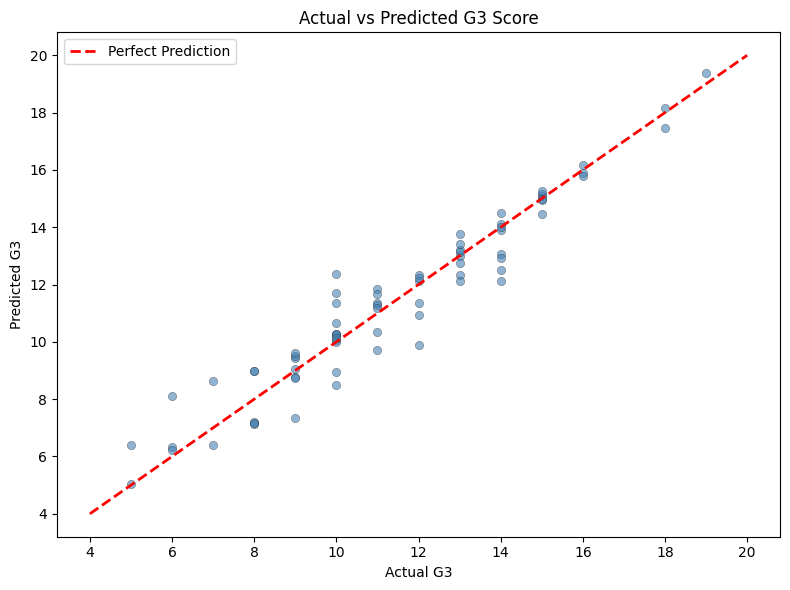

In [17]:

# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted G3 Score')
plt.legend()
plt.tight_layout()
plt.show()





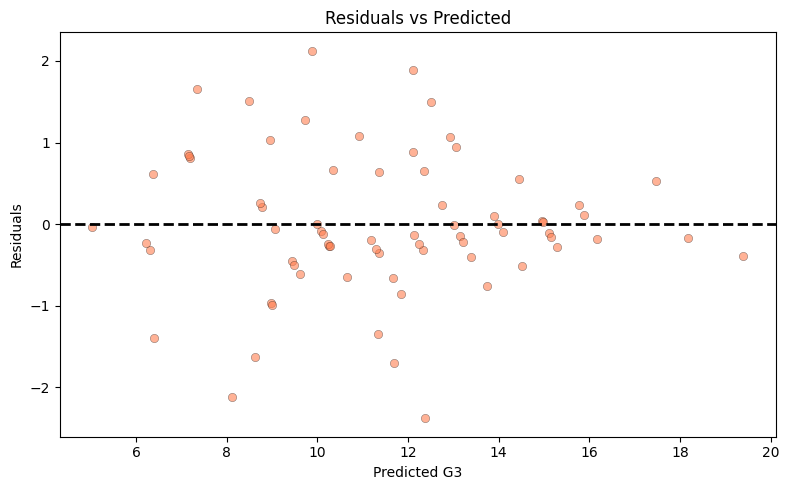

In [18]:
residuals = y_test- y_pred_test
plt.figure(figsize=(8,5))
plt.scatter(y_pred_test, residuals, alpha=0.6, color='coral', edgecolors='k', linewidths=0.3)
plt.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted G3')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()


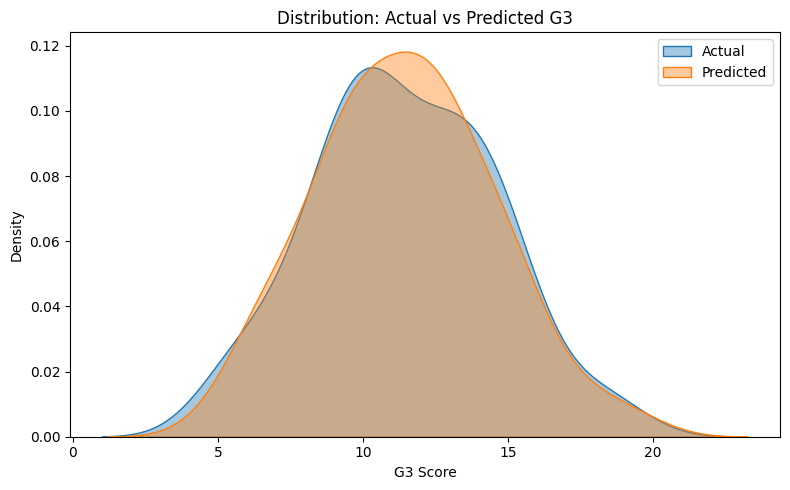

 Actual  Predicted  Error
     12      12.32  -0.32
     18      18.17  -0.17
     11      11.36  -0.36
      9       9.45  -0.45
     15      15.10  -0.10
      9       7.35   1.65
     14      14.10  -0.10
     15      15.16  -0.16
      9       8.79   0.21
      8       7.19   0.81
      6       6.32  -0.32
      5       5.04  -0.04
     12      11.36   0.64
     11      10.34   0.66
     13      13.01  -0.01
     11       9.72   1.28
     11      11.30  -0.30
     13      13.15  -0.15
     14      13.05   0.95
     16      15.89   0.11
     10      10.27  -0.27
     12      12.13  -0.13
      9       9.06  -0.06
     12       9.88   2.12
     16      16.18  -0.18
     12      12.24  -0.24
      7       8.63  -1.63
     13      13.21  -0.21
      8       8.97  -0.97
     14      12.11   1.89
     11      11.85  -0.85
     15      14.96   0.04
     10      10.24  -0.24
     10      10.27  -0.27
     19      19.39  -0.39
     13      13.40  -0.40
     16      15.77   0.23
     10     

In [19]:
plt.figure(figsize=(8,5))
sns.kdeplot(y_test, label='Actual', fill=True, alpha=0.4)
sns.kdeplot(y_pred_test, label='Predicted', fill=True, alpha=0.4)
plt.xlabel('G3 Score')
plt.title('Distribution: Actual vs Predicted G3')
plt.legend()
plt.tight_layout()
plt.show()

# Actual vs Predicted table
results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_test.round(2), 'Error': (y_test.values - y_pred_test).round(2)})
print(results_df.to_string(index=False))